In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set plot style
plt.style.use('ggplot')

In [2]:
df = pd.read_csv("Cleaned_Amazon_Sales.csv")
df.head()

,index,Order ID,Date,Status,Fulfilment,Sales Channel,ship-service-level,Category,Size,Courier Status,...,currency,Amount,ship-city,ship-state,ship-postal-code,ship-country,B2B,fulfilled-by,New,PendingS
0,0,405-8078784-5731545,2022-04-30,Cancelled,Merchant,Amazon.in,Standard,T-shirt,S,On the Way,...,INR,647.62,MUMBAI,MAHARASHTRA,400081.0,IN,False,Easy Ship,NaN,NaN
1,1,171-9198151-1101146,2022-04-30,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,Shirt,3XL,Shipped,...,INR,406.00,BENGALURU,KARNATAKA,560085.0,IN,False,Easy Ship,NaN,NaN
2,2,404-0687676-7273146,2022-04-30,Shipped,Amazon,Amazon.in,Expedited,Shirt,XL,Shipped,...,INR,329.00,NAVI MUMBAI,MAHARASHTRA,410210.0,IN,True,Not Specified,NaN,NaN
3,3,403-9615377-8133951,2022-04-30,Cancelled,Merchant,Amazon.in,Standard,Blazzer,L,On the Way,...,INR,753.33,PUDUCHERRY,PUDUCHERRY,605008.0,IN,False,Easy Ship,NaN,NaN
4,4,407-1069790-7240320,2022-04-30,Shipped,Amazon,Amazon.in,Expedited,Trousers,3XL,Shipped,...,INR,574.00,CHENNAI,TAMIL NADU,600073.0,IN,False,Not Specified,NaN,NaN


In [3]:
print("Rows and Columns:", df.shape)

Rows and Columns: (121019, 21)


In [4]:
df.dtypes

index                   int64
Order ID               object
Date                   object
Status                 object
Fulfilment             object
Sales Channel          object
ship-service-level     object
Category               object
Size                   object
Courier Status         object
Qty                     int64
currency               object
Amount                float64
ship-city              object
ship-state             object
ship-postal-code      float64
ship-country           object
B2B                      bool
fulfilled-by           object
New                   float64
PendingS              float64
dtype: object

In [5]:
df.describe()

,index,Qty,Amount,ship-postal-code,New,PendingS
count,121019.000000,121019.000000,121019.000000,120988.000000,0.0,0.0
mean,64562.667143,0.961246,648.631921,463633.868888,NaN,NaN
std,37183.193053,0.214311,281.224583,191322.751791,NaN,NaN
min,0.000000,0.000000,0.000000,110001.000000,NaN,NaN
25%,32420.500000,1.000000,449.000000,382421.000000,NaN,NaN
50%,64565.000000,1.000000,605.000000,500032.000000,NaN,NaN
75%,96720.500000,1.000000,788.000000,600021.000000,NaN,NaN
max,128974.000000,8.000000,5584.000000,989898.000000,NaN,NaN


In [6]:
df.describe(include='object')

,Order ID,Date,Status,Fulfilment,Sales Channel,ship-service-level,Category,Size,Courier Status,currency,ship-city,ship-state,ship-country,fulfilled-by
count,121019,121019,121019,121019,121019,121019,121019,121019,121019,121019,120988,120988,120988,121019
unique,112887,91,12,2,1,2,9,11,3,1,8697,68,1,2
top,171-5057375-2831560,2022-02-05,Shipped,Amazon,Amazon.in,Expedited,T-shirt,M,Shipped,INR,BENGALURU,MAHARASHTRA,IN,Not Specified
freq,12,1932,77505,83542,121019,82627,46980,20948,109341,121019,10659,21048,120988,83542


In [7]:
df.isnull().sum()

index                      0
Order ID                   0
Date                       0
Status                     0
Fulfilment                 0
Sales Channel              0
ship-service-level         0
Category                   0
Size                       0
Courier Status             0
Qty                        0
currency                   0
Amount                     0
ship-city                 31
ship-state                31
ship-postal-code          31
ship-country              31
B2B                        0
fulfilled-by               0
New                   121019
PendingS              121019
dtype: int64

In [8]:
print("Total Orders:", df['Order ID'].nunique())

Total Orders: 112887


In [9]:
print("Total Revenue: ₹{:,.2f}".format(df['Amount'].sum()))

Total Revenue: ₹78,496,786.39


In [10]:
print("Average Order Value: ₹{:.2f}".format(df['Amount'].mean()))

Average Order Value: ₹648.63


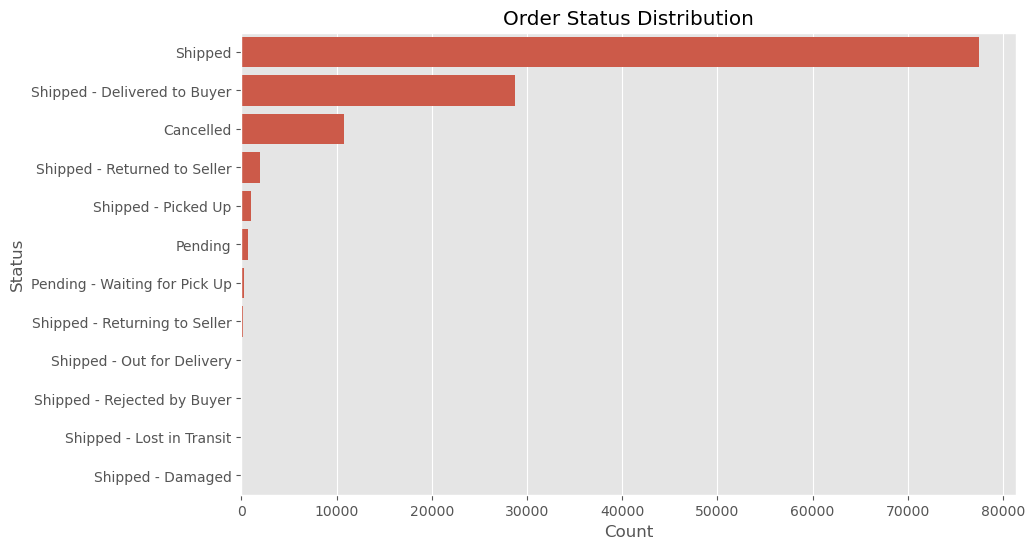

In [11]:
plt.figure(figsize=(10,6))
sns.countplot(y='Status', data=df, order=df['Status'].value_counts().index)
plt.title("Order Status Distribution")
plt.xlabel("Count")
plt.ylabel("Status")
plt.show()

Insight: Identify which order status (e.g., Shipped, Cancelled) occurs most frequently.

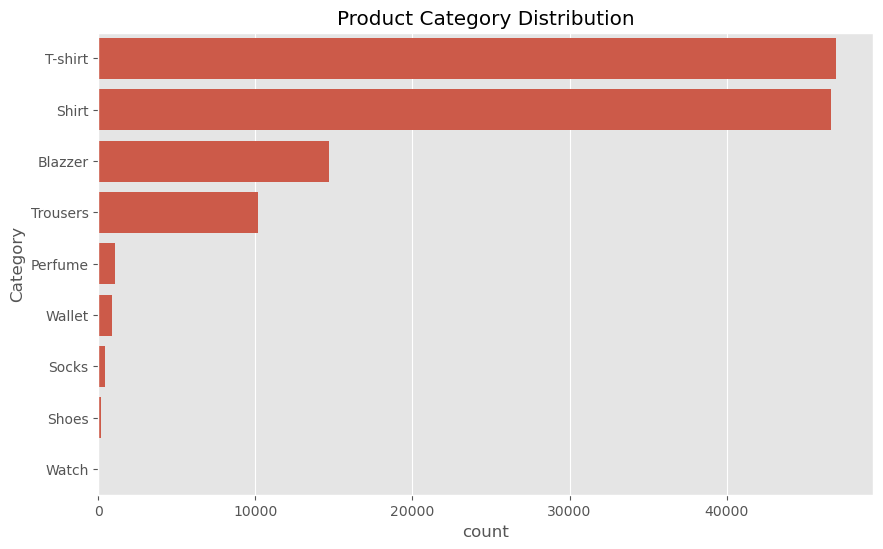

In [12]:
plt.figure(figsize=(10,6))
sns.countplot(y='Category', data=df, order=df['Category'].value_counts().index)
plt.title("Product Category Distribution")
plt.show()

Insight: Shows the most popular product categories.

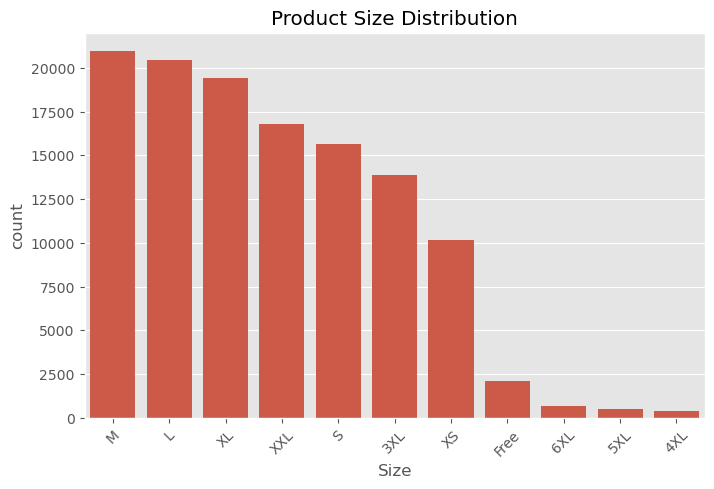

In [13]:
plt.figure(figsize=(8,5))
sns.countplot(x='Size', data=df, order=df['Size'].value_counts().index)
plt.title("Product Size Distribution")
plt.xticks(rotation=45)
plt.show()

Insight: Identify the most frequently ordered size.

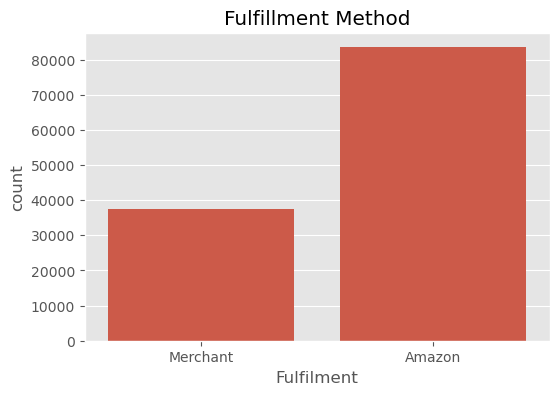

In [14]:
plt.figure(figsize=(6,4))
sns.countplot(x='Fulfilment', data=df)
plt.title("Fulfillment Method")
plt.show()

Insight: Compare Amazon Fulfillment vs Merchant Fulfillment.

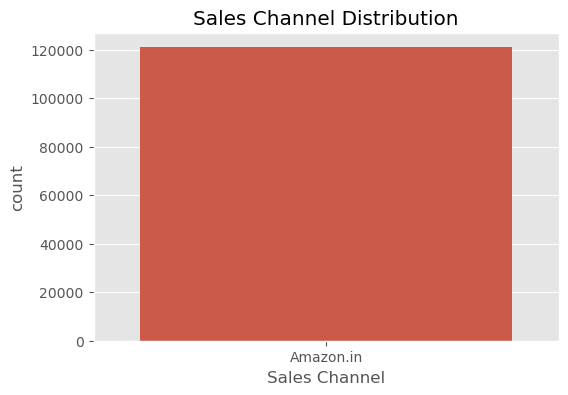

In [15]:
plt.figure(figsize=(6,4))
sns.countplot(x='Sales Channel', data=df)
plt.title("Sales Channel Distribution")
plt.show()

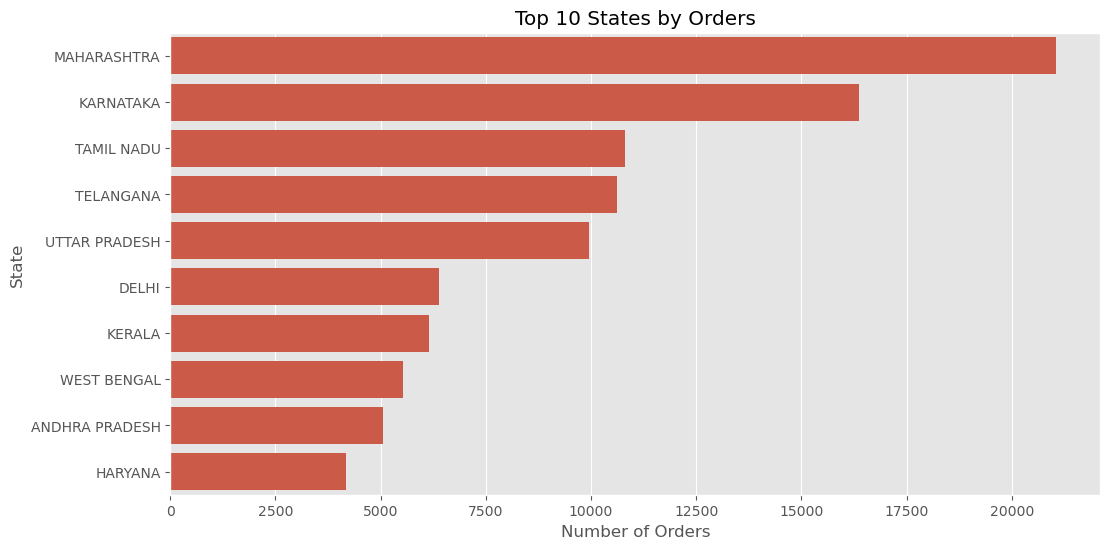

In [16]:
top_states = df['ship-state'].value_counts().head(10)

plt.figure(figsize=(12,6))
sns.barplot(x=top_states.values, y=top_states.index)
plt.title("Top 10 States by Orders")
plt.xlabel("Number of Orders")
plt.ylabel("State")
plt.show()

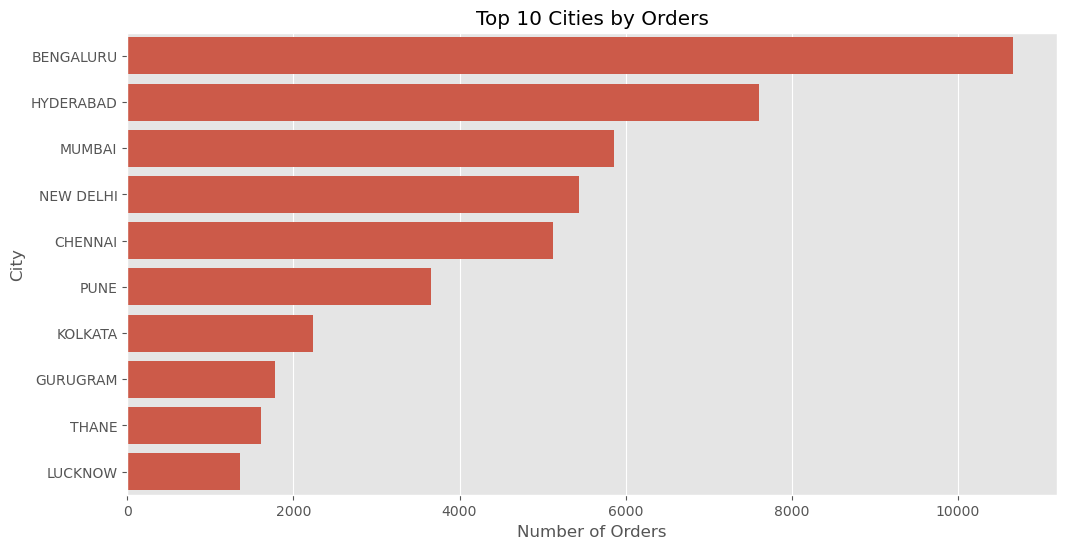

In [17]:
top_cities = df['ship-city'].value_counts().head(10)

plt.figure(figsize=(12,6))
sns.barplot(x=top_cities.values, y=top_cities.index)
plt.title("Top 10 Cities by Orders")
plt.xlabel("Number of Orders")
plt.ylabel("City")
plt.show()

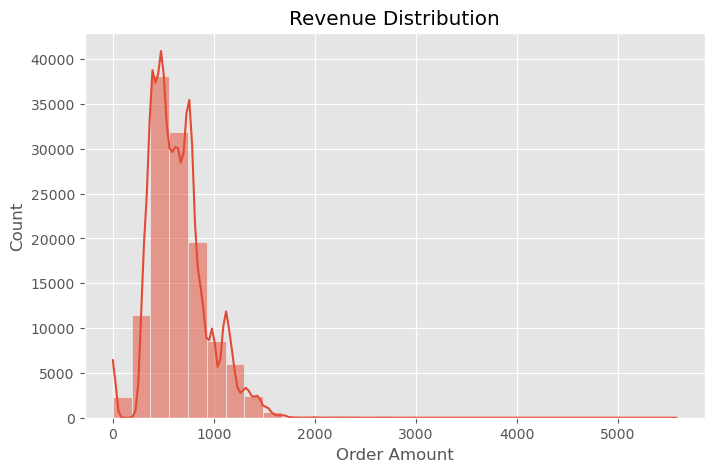

In [18]:
plt.figure(figsize=(8,5))
sns.histplot(df['Amount'], bins=30, kde=True)
plt.title("Revenue Distribution")
plt.xlabel("Order Amount")
plt.show()

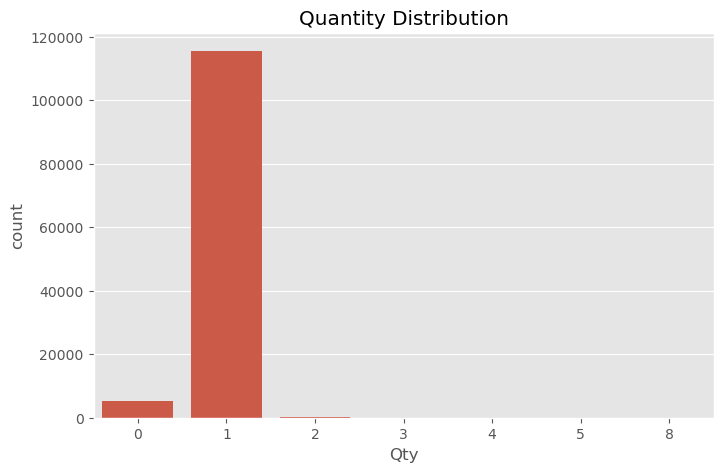

In [19]:
plt.figure(figsize=(8,5))
sns.countplot(x='Qty', data=df)
plt.title("Quantity Distribution")
plt.show()

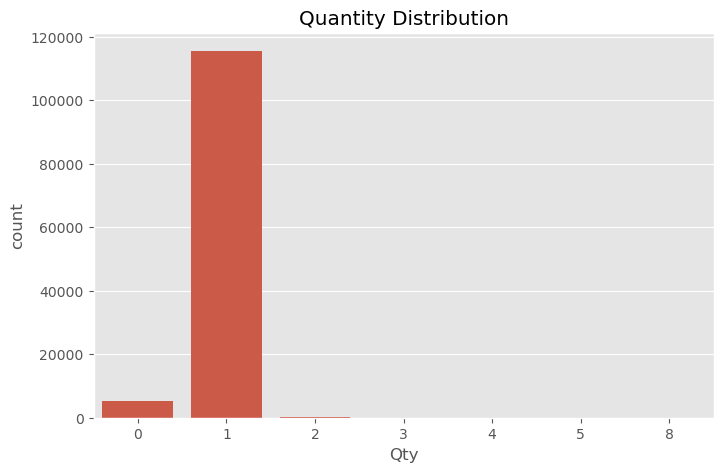

In [20]:
plt.figure(figsize=(8,5))
sns.countplot(x='Qty', data=df)
plt.title("Quantity Distribution")
plt.show()

In [21]:
total_revenue = df['Amount'].sum()
print(f"Total Revenue: ₹{total_revenue:,.2f}")

Total Revenue: ₹78,496,786.39


In [22]:
total_orders = df['Order ID'].nunique()
print("Total Orders:", total_orders)

Total Orders: 112887


In [23]:
total_quantity = df['Qty'].sum()
print("Total Quantity Sold:", total_quantity)

Total Quantity Sold: 116329


In [24]:
average_order = df['Amount'].mean()
print(f"Average Order Value: ₹{average_order:.2f}")

Average Order Value: ₹648.63


In [26]:
#Create a month column:
df['Date'] = pd.to_datetime(df['Date'])

df['Month'] = df['Date'].dt.to_period('M')

In [27]:
#Calculate monthly revenue:
monthly_sales = df.groupby('Month')['Amount'].sum().reset_index()

monthly_sales['Month'] = monthly_sales['Month'].astype(str)

monthly_sales

,Month,Amount
0,2022-01,2880866.33
1,2022-02,2982101.41
2,2022-03,3042310.01
3,2022-04,20404203.09
4,2022-05,17821991.32
5,2022-06,15262409.88
6,2022-07,2787150.37
7,2022-08,2886262.76
8,2022-09,2742205.46
9,2022-10,2597647.85


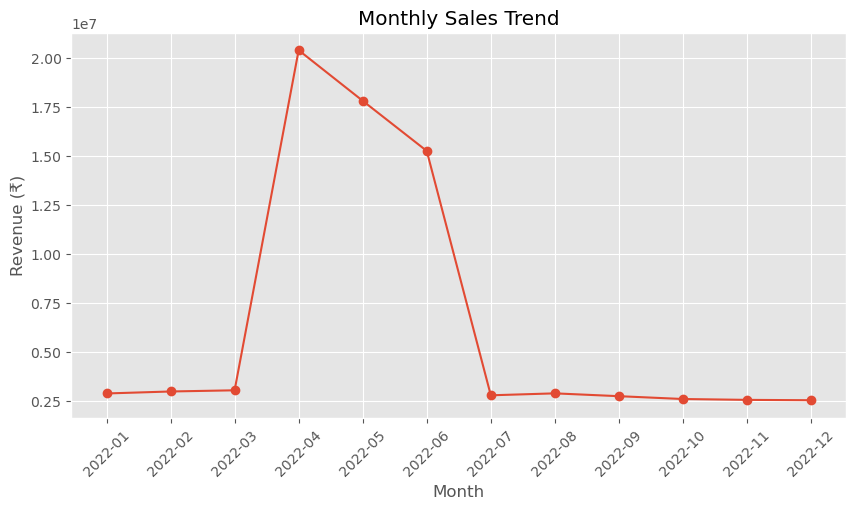

In [28]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(monthly_sales['Month'],
         monthly_sales['Amount'],
         marker='o')

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Revenue (₹)")
plt.xticks(rotation=45)

plt.show()

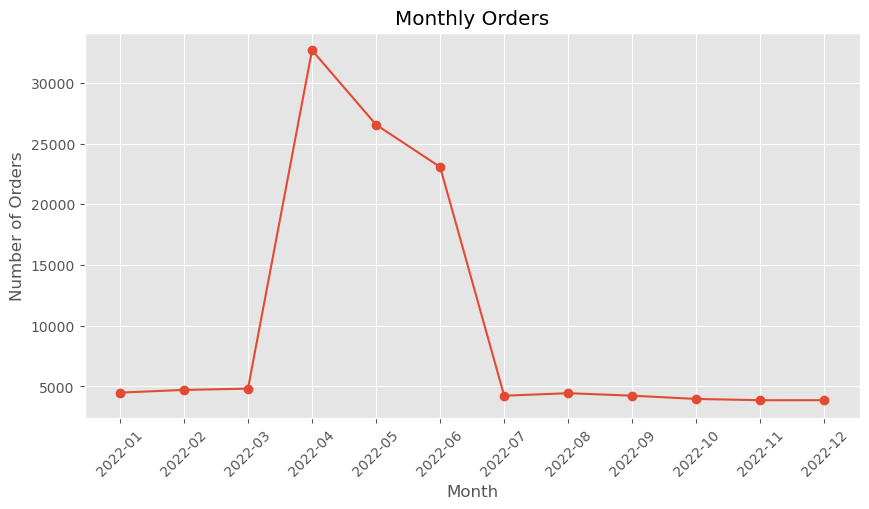

In [29]:
monthly_orders = df.groupby('Month')['Order ID'].count().reset_index()

monthly_orders['Month'] = monthly_orders['Month'].astype(str)

plt.figure(figsize=(10,5))

plt.plot(monthly_orders['Month'],
         monthly_orders['Order ID'],
         marker='o')

plt.title("Monthly Orders")
plt.xlabel("Month")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)

plt.show()

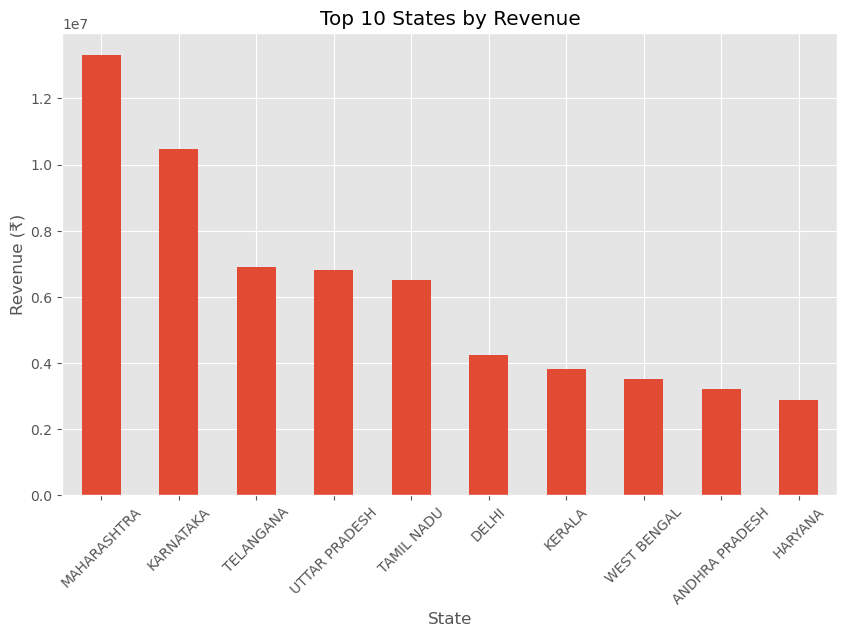

In [30]:
top_states = df.groupby('ship-state')['Amount'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))

top_states.plot(kind='bar')

plt.title("Top 10 States by Revenue")
plt.xlabel("State")
plt.ylabel("Revenue (₹)")
plt.xticks(rotation=45)

plt.show()

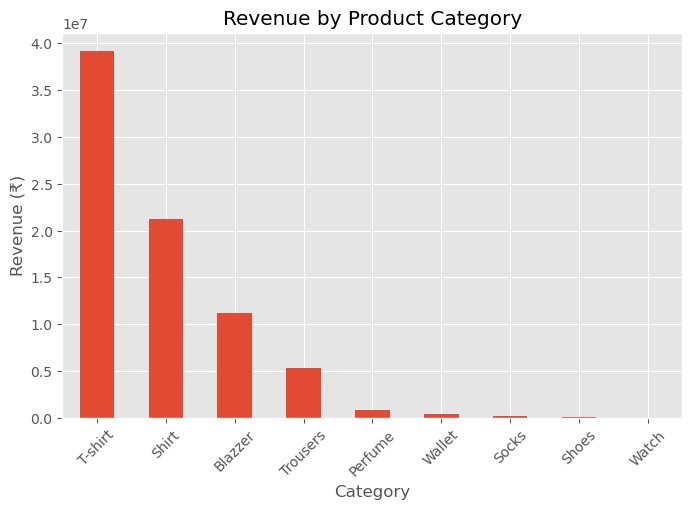

In [31]:
top_category = df.groupby('Category')['Amount'].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))

top_category.plot(kind='bar')

plt.title("Revenue by Product Category")
plt.xlabel("Category")
plt.ylabel("Revenue (₹)")
plt.xticks(rotation=45)

plt.show()

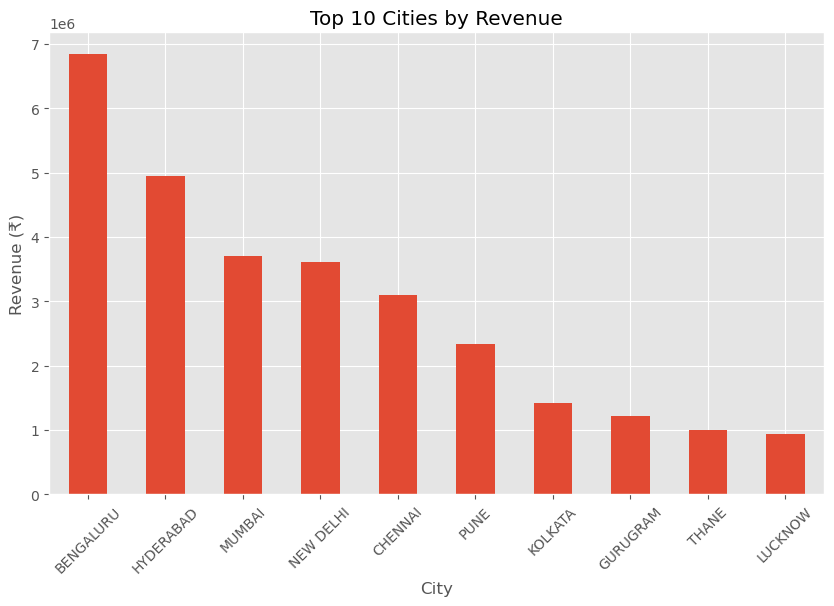

In [32]:
top_city = df.groupby('ship-city')['Amount'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))

top_city.plot(kind='bar')

plt.title("Top 10 Cities by Revenue")
plt.xlabel("City")
plt.ylabel("Revenue (₹)")
plt.xticks(rotation=45)

plt.show()

In [37]:
category_count = df['Category'].value_counts()
print(category_count)

Category
T-shirt     46980
Shirt       46645
Blazzer     14694
Trousers    10151
Perfume      1091
Wallet        881
Socks         419
Shoes         155
Watch           3
Name: count, dtype: int64


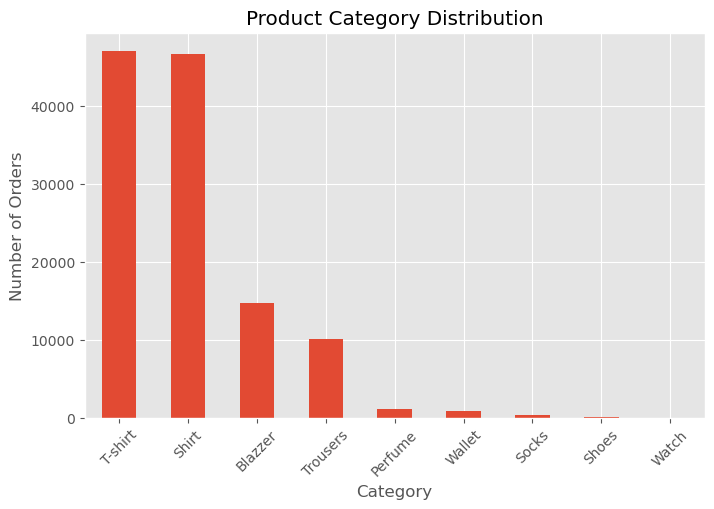

In [38]:
plt.figure(figsize=(8,5))

category_count.plot(kind='bar')

plt.title("Product Category Distribution")
plt.xlabel("Category")
plt.ylabel("Number of Orders")

plt.xticks(rotation=45)

plt.show()

Insight: This chart shows which product category has the highest number of orders.

In [39]:
category_revenue = df.groupby('Category')['Amount'].sum().sort_values(ascending=False)

print(category_revenue)

Category
T-shirt     39154132.17
Shirt       21269768.70
Blazzer     11208506.12
Trousers     5341305.30
Perfume       789419.66
Wallet        458408.18
Socks         150397.50
Shoes         123933.76
Watch            915.00
Name: Amount, dtype: float64


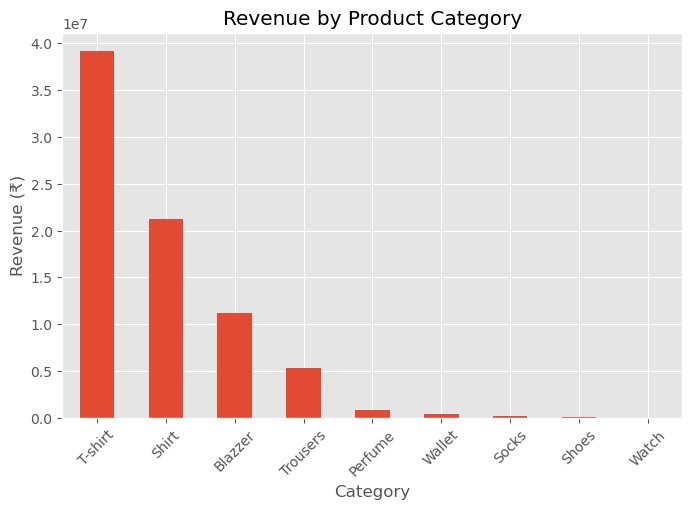

In [40]:
plt.figure(figsize=(8,5))

category_revenue.plot(kind='bar')

plt.title("Revenue by Product Category")
plt.xlabel("Category")
plt.ylabel("Revenue (₹)")

plt.xticks(rotation=45)

plt.show()

Insight: Identify the category that generates the highest revenue.

In [41]:
size_count = df['Size'].value_counts()

print(size_count)

Size
M       20948
L       20461
XL      19394
XXL     16767
S       15630
3XL     13870
XS      10180
Free     2130
6XL       705
5XL       526
4XL       408
Name: count, dtype: int64


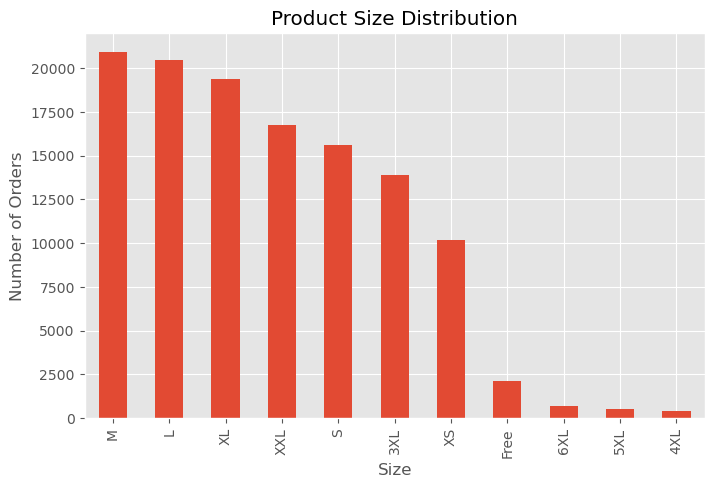

In [42]:
plt.figure(figsize=(8,5))

size_count.plot(kind='bar')

plt.title("Product Size Distribution")
plt.xlabel("Size")
plt.ylabel("Number of Orders")

plt.show()

Insight: Find the most popular clothing size.

In [43]:
qty_category = df.groupby('Category')['Qty'].sum().sort_values(ascending=False)

print(qty_category)

Category
T-shirt     45164
Shirt       44903
Blazzer     13930
Trousers     9885
Perfume      1051
Wallet        844
Socks         397
Shoes         152
Watch           3
Name: Qty, dtype: int64


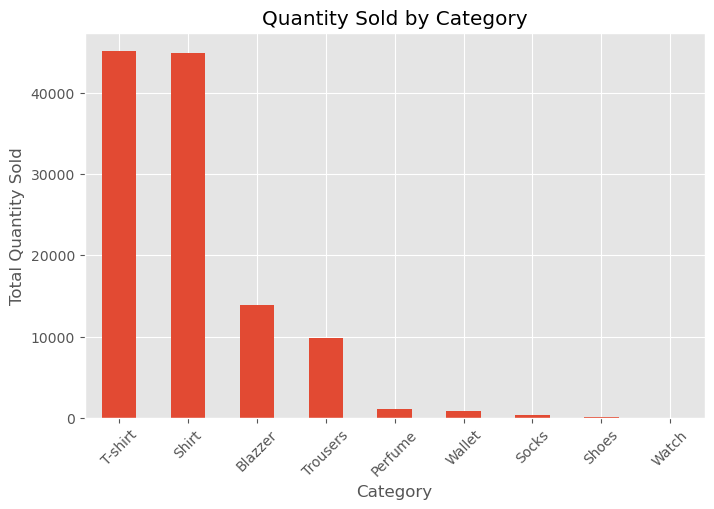

In [44]:
plt.figure(figsize=(8,5))

qty_category.plot(kind='bar')

plt.title("Quantity Sold by Category")
plt.xlabel("Category")
plt.ylabel("Total Quantity Sold")

plt.xticks(rotation=45)

plt.show()

Insight: Shows which category sold the highest number of items.

Category
T-shirt     39154132.17
Shirt       21269768.70
Blazzer     11208506.12
Trousers     5341305.30
Perfume       789419.66
Wallet        458408.18
Socks         150397.50
Shoes         123933.76
Watch            915.00
Name: Amount, dtype: float64


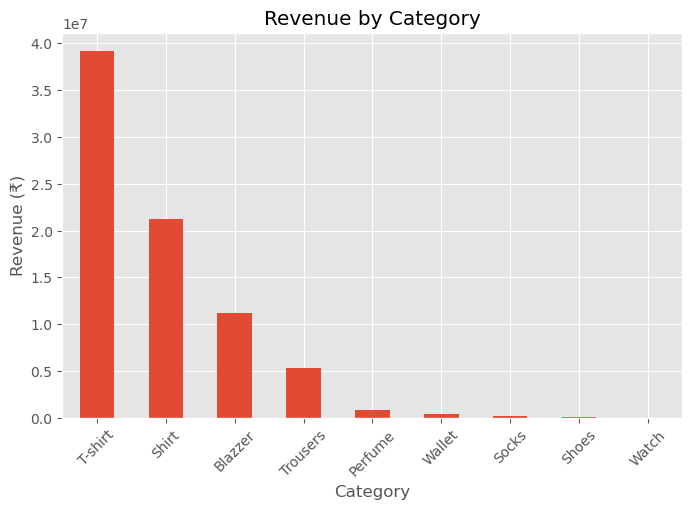

In [48]:
top_categories = df.groupby('Category')['Amount'].sum().sort_values(ascending=False)

print(top_categories)

plt.figure(figsize=(8,5))
top_categories.plot(kind='bar')

plt.title("Revenue by Category")
plt.xlabel("Category")
plt.ylabel("Revenue (₹)")
plt.xticks(rotation=45)
plt.show()

Category
T-shirt     45164
Shirt       44903
Blazzer     13930
Trousers     9885
Perfume      1051
Wallet        844
Socks         397
Shoes         152
Watch           3
Name: Qty, dtype: int64


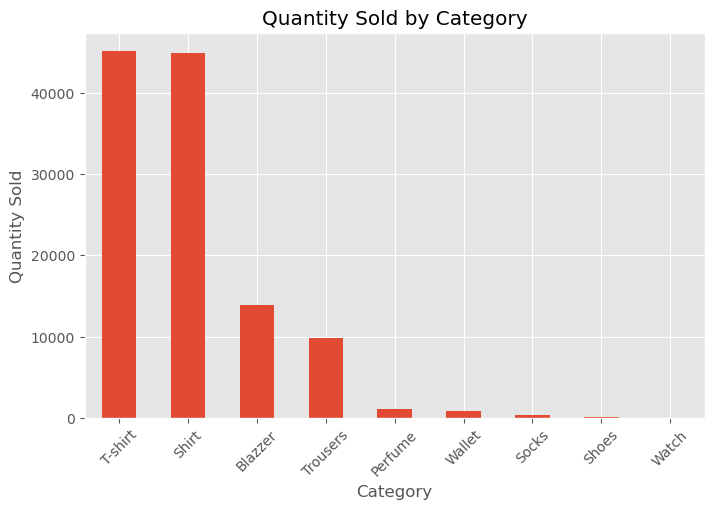

In [49]:
category_qty = df.groupby('Category')['Qty'].sum().sort_values(ascending=False)

print(category_qty)

plt.figure(figsize=(8,5))
category_qty.plot(kind='bar')

plt.title("Quantity Sold by Category")
plt.xlabel("Category")
plt.ylabel("Quantity Sold")
plt.xticks(rotation=45)
plt.show()

Fulfilment
Amazon      83542
Merchant    37477
Name: count, dtype: int64


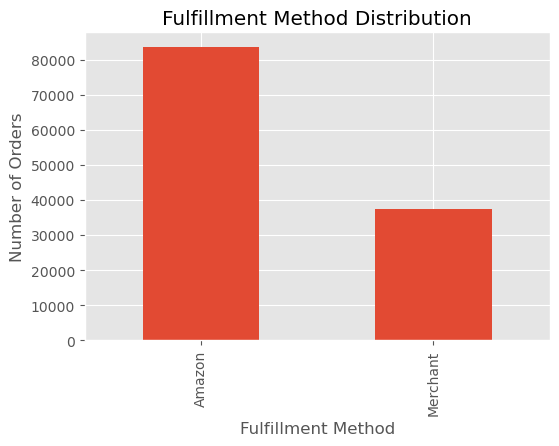

In [50]:
print(df['Fulfilment'].value_counts())

plt.figure(figsize=(6,4))
df['Fulfilment'].value_counts().plot(kind='bar')

plt.title("Fulfillment Method Distribution")
plt.xlabel("Fulfillment Method")
plt.ylabel("Number of Orders")
plt.show()

Fulfilment
Amazon      54262165.00
Merchant    24234621.39
Name: Amount, dtype: float64


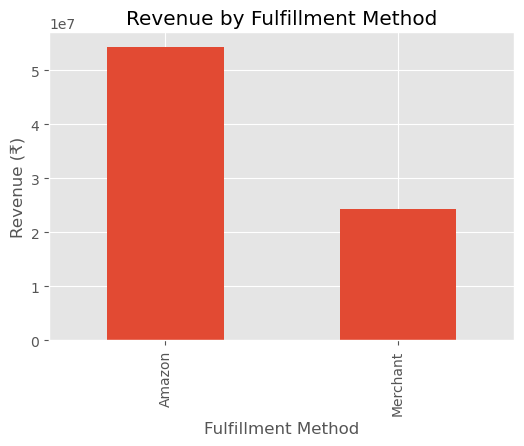

In [51]:
fulfillment_revenue = df.groupby('Fulfilment')['Amount'].sum()

print(fulfillment_revenue)

plt.figure(figsize=(6,4))
fulfillment_revenue.plot(kind='bar')

plt.title("Revenue by Fulfillment Method")
plt.xlabel("Fulfillment Method")
plt.ylabel("Revenue (₹)")
plt.show()

Fulfilment                     Amazon  Merchant
Status                                         
Cancelled                        5624      5127
Pending                           413       243
Pending - Waiting for Pick Up       0       281
Shipped                         77505         0
Shipped - Damaged                   0         1
Shipped - Delivered to Buyer        0     28707
Shipped - Lost in Transit           0         5
Shipped - Out for Delivery          0        35
Shipped - Picked Up                 0       973
Shipped - Rejected by Buyer         0        11
Shipped - Returned to Seller        0      1949
Shipped - Returning to Seller       0       145


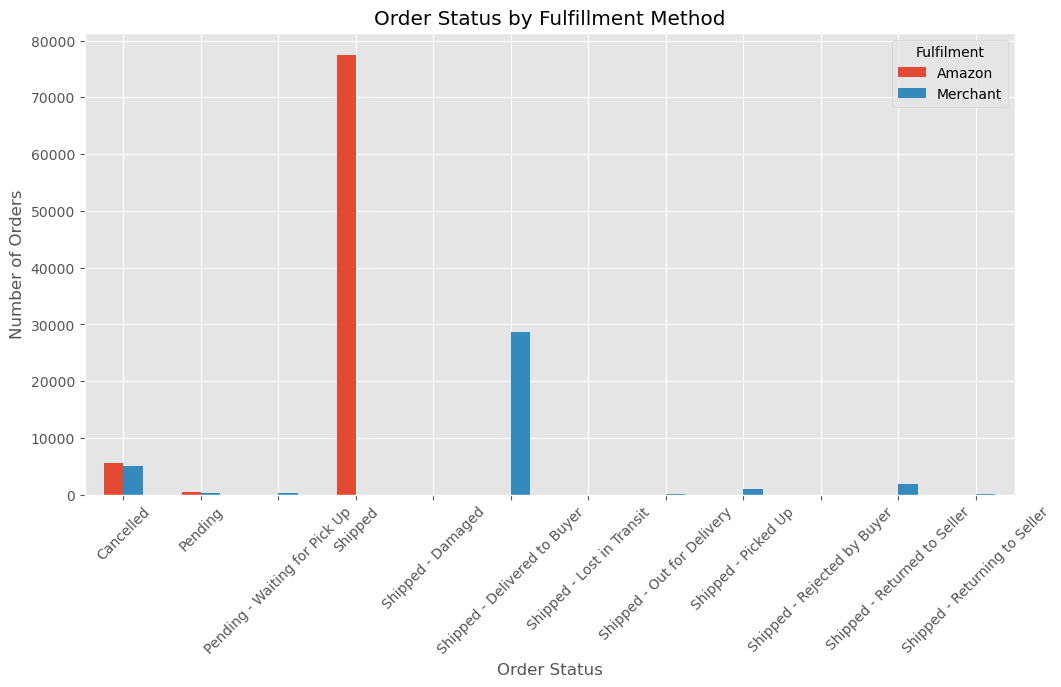

In [52]:
status_fulfillment = pd.crosstab(df['Status'], df['Fulfilment'])

print(status_fulfillment)

status_fulfillment.plot(kind='bar', figsize=(12,6))

plt.title("Order Status by Fulfillment Method")
plt.xlabel("Order Status")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)
plt.show()

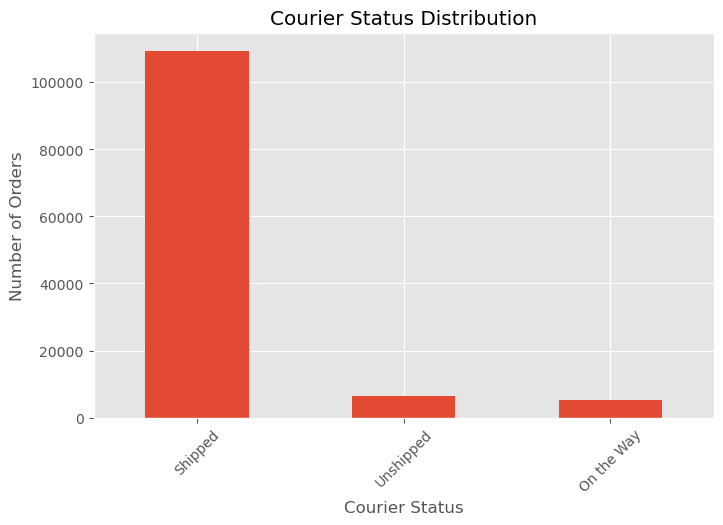

In [53]:
plt.figure(figsize=(8,5))
df['Courier Status'].value_counts().plot(kind='bar')

plt.title("Courier Status Distribution")
plt.xlabel("Courier Status")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)
plt.show()

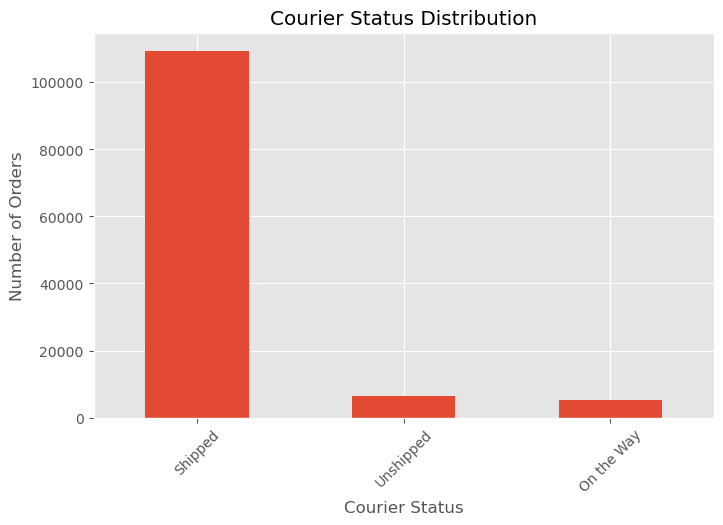

In [54]:
plt.figure(figsize=(8,5))
df['Courier Status'].value_counts().plot(kind='bar')

plt.title("Courier Status Distribution")
plt.xlabel("Courier Status")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)
plt.show()

B2B
False    120176
True        843
Name: count, dtype: int64


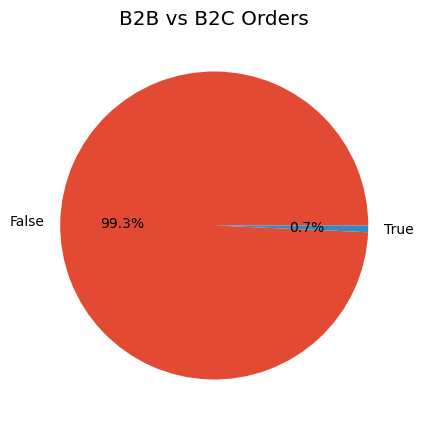

In [55]:
print(df['B2B'].value_counts())

plt.figure(figsize=(5,5))
df['B2B'].value_counts().plot(kind='pie', autopct='%1.1f%%')

plt.ylabel("")
plt.title("B2B vs B2C Orders")
plt.show()

B2B
False    120176
True        843
Name: count, dtype: int64


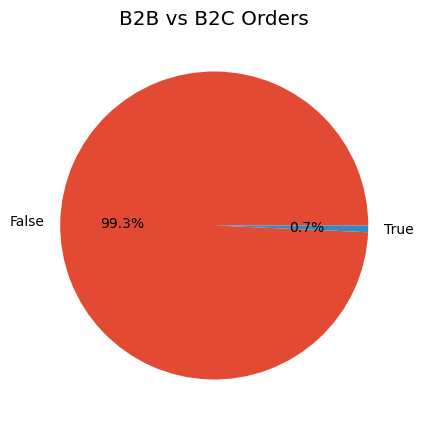

In [56]:
print(df['B2B'].value_counts())

plt.figure(figsize=(5,5))
df['B2B'].value_counts().plot(kind='pie', autopct='%1.1f%%')

plt.ylabel("")
plt.title("B2B vs B2C Orders")
plt.show()

ship-state
MAHARASHTRA       21048
KARNATAKA         16364
TAMIL NADU        10796
TELANGANA         10626
UTTAR PRADESH      9943
DELHI              6381
KERALA             6140
WEST BENGAL        5540
ANDHRA PRADESH     5046
HARYANA            4182
Name: count, dtype: int64


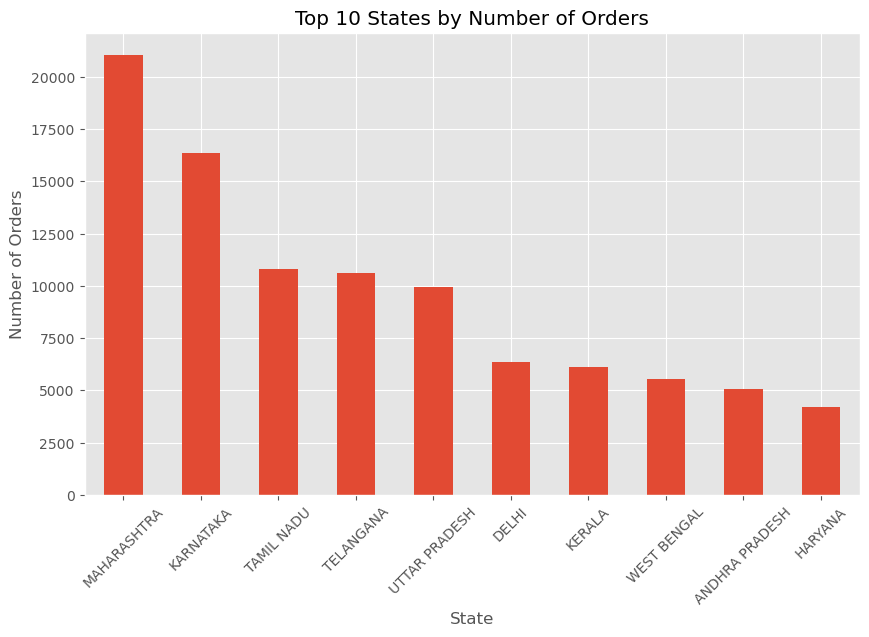

In [57]:
top_states = df['ship-state'].value_counts().head(10)

print(top_states)

plt.figure(figsize=(10,6))
top_states.plot(kind='bar')

plt.title("Top 10 States by Number of Orders")
plt.xlabel("State")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)

plt.show()

Insight: This chart shows the states with the highest number of customer orders.

ship-state
MAHARASHTRA       13318966.38
KARNATAKA         10465387.03
TELANGANA          6909670.08
UTTAR PRADESH      6814126.08
TAMIL NADU         6510503.73
DELHI              4228503.97
KERALA             3821997.58
WEST BENGAL        3503223.44
ANDHRA PRADESH     3214859.86
HARYANA            2879146.99
Name: Amount, dtype: float64


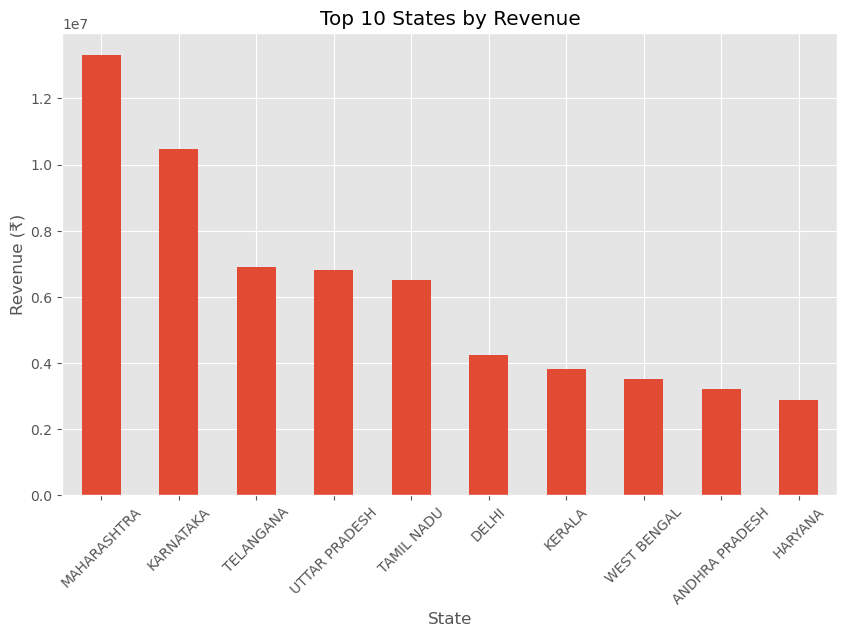

In [58]:
state_revenue = df.groupby('ship-state')['Amount'].sum().sort_values(ascending=False).head(10)

print(state_revenue)

plt.figure(figsize=(10,6))
state_revenue.plot(kind='bar')

plt.title("Top 10 States by Revenue")
plt.xlabel("State")
plt.ylabel("Revenue (₹)")
plt.xticks(rotation=45)

plt.show()

ship-city
BENGALURU    10659
HYDERABAD     7599
MUMBAI        5856
NEW DELHI     5439
CHENNAI       5130
PUNE          3656
KOLKATA       2242
GURUGRAM      1780
THANE         1606
LUCKNOW       1354
Name: count, dtype: int64


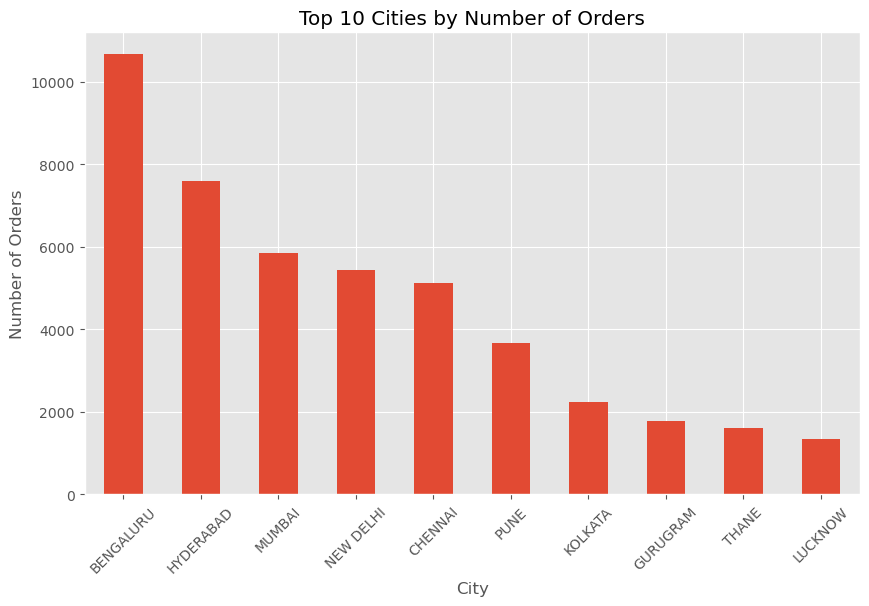

In [59]:
top_cities = df['ship-city'].value_counts().head(10)

print(top_cities)

plt.figure(figsize=(10,6))
top_cities.plot(kind='bar')

plt.title("Top 10 Cities by Number of Orders")
plt.xlabel("City")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)

plt.show()

ship-city
BENGALURU    6836614.65
HYDERABAD    4941790.25
MUMBAI       3696704.04
NEW DELHI    3608277.78
CHENNAI      3098745.74
PUNE         2337978.18
KOLKATA      1412815.87
GURUGRAM     1220562.74
THANE        1003878.29
LUCKNOW       933926.34
Name: Amount, dtype: float64


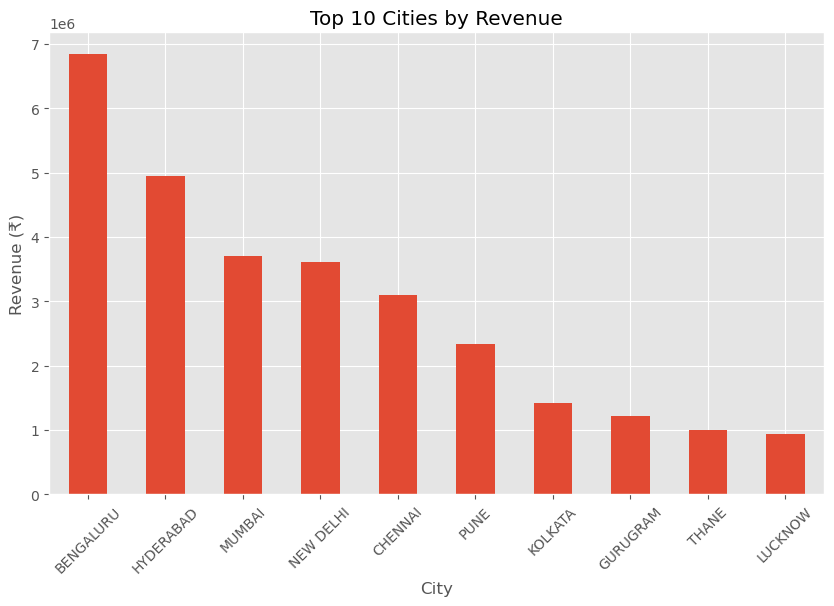

In [60]:
city_revenue = df.groupby('ship-city')['Amount'].sum().sort_values(ascending=False).head(10)

print(city_revenue)

plt.figure(figsize=(10,6))
city_revenue.plot(kind='bar')

plt.title("Top 10 Cities by Revenue")
plt.xlabel("City")
plt.ylabel("Revenue (₹)")
plt.xticks(rotation=45)

plt.show()

ship-country
IN    78478115.39
Name: Amount, dtype: float64


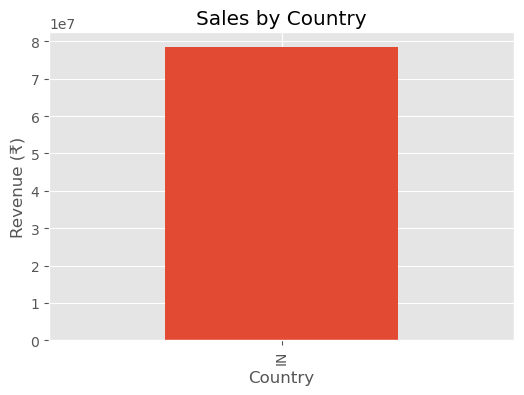

In [61]:
country_sales = df.groupby('ship-country')['Amount'].sum()

print(country_sales)

plt.figure(figsize=(6,4))
country_sales.plot(kind='bar')

plt.title("Sales by Country")
plt.xlabel("Country")
plt.ylabel("Revenue (₹)")

plt.show()

ship-postal-code
201301.0    959
122001.0    648
560037.0    602
560068.0    583
560076.0    552
560043.0    463
560100.0    460
401107.0    460
500072.0    454
560066.0    443
Name: count, dtype: int64


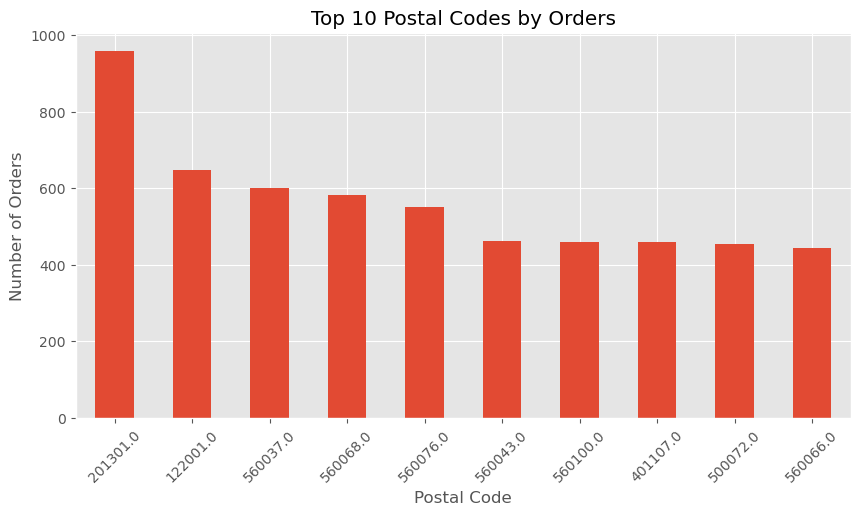

In [62]:
top_postal = df['ship-postal-code'].value_counts().head(10)

print(top_postal)

plt.figure(figsize=(10,5))
top_postal.plot(kind='bar')

plt.title("Top 10 Postal Codes by Orders")
plt.xlabel("Postal Code")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)

plt.show()